# Prepare df_ssp for plots and stats

In [1]:
# import all packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

### Import output data for all SSPs

In [2]:
from get_df_ssp import get_df_ssp
df_ssp = get_df_ssp()

(30544, 24) (30544, 23) (30544, 24) (30533, 29) (30498, 29) (30533, 29)
(30498, 47) (30544, 42)
Total number of cities 30498


In [3]:
df_ssp[['GEOID', 'NAMELSAD', 'city type', 'REGION', 'CensusPop_20','length_m_perCap_2020_ssp2']].sort_values('length_m_perCap_2020_ssp2').head(10)

,GEOID,NAMELSAD,city type,REGION,CensusPop_20,length_m_perCap_2020_ssp2
5621,1510900,Haliimaile CDP,rural,West,1074.0,0.010721
3846,0966086,Sacred Heart University CDP,suburban,Northeast,1446.0,0.011010
16689,3470984,Stockton University CDP,rural,Northeast,2428.0,0.013453
2741,0645806,Marina del Rey CDP,urban,West,11373.0,0.030026
2966,0663218,Rowland Heights CDP,periurban,West,48231.0,0.076951
24832,4612340,Clark Colony CDP,rural,Midwest,92.0,0.079107
21995,4105700,Bellfountain CDP,rural,West,74.0,0.097568
3048,0673430,South Whittier CDP,periurban,West,56415.0,0.146627
2143,0601150,Alondra Park CDP,urban,West,8569.0,0.183723
2520,0631596,Hacienda Heights CDP,periurban,West,54191.0,0.206098


### Percent cities with increasing burden from 2020 to 2100

In [4]:
print('Cities with an increasing burden at each scenario ====')
print("For buildings=== ssp2, ssp1 , ssp4 ")
print(df_ssp[df_ssp['volume_m3_perCap_2020_ssp2'] < df_ssp['volume_m3_perCap_2100_ssp2']].shape[0] / df_ssp['volume_m3_perCap_2100_ssp2'].shape[0],\
     df_ssp[df_ssp['volume_m3_perCap_2020_ssp1'] < df_ssp['volume_m3_perCap_2100_ssp1']].shape[0] / df_ssp['volume_m3_perCap_2100_ssp1'].shape[0],  \
        df_ssp[df_ssp['volume_m3_perCap_2020_ssp4'] < df_ssp['volume_m3_perCap_2100_ssp4']].shape[0] / df_ssp['volume_m3_perCap_2100_ssp4'].shape[0])
print("For roadways=== ssp2, ssp1 , ssp4 ")
print(df_ssp[df_ssp['length_m_perCap_2020_ssp2'] < df_ssp['length_m_perCap_2100_ssp2']].shape[0] / df_ssp['volume_m3_perCap_2100_ssp2'].shape[0], \
df_ssp[df_ssp['length_m_perCap_2020_ssp1'] < df_ssp['length_m_perCap_2100_ssp1']].shape[0] / df_ssp['volume_m3_perCap_2100_ssp1'].shape[0], \
df_ssp[df_ssp['length_m_perCap_2020_ssp4'] < df_ssp['length_m_perCap_2100_ssp4']].shape[0] / df_ssp['volume_m3_perCap_2100_ssp4'].shape[0] )

Cities with an increasing burden at each scenario ====
For buildings=== ssp2, ssp1 , ssp4 
0.5843989769820972 0.6009246507967736 0.8293986490917438
For roadways=== ssp2, ssp1 , ssp4 
0.5320020984982622 0.5213128729752771 0.7235556429929831


### Regional decriptive stats by city type

In [5]:
df_ssp.groupby(['city type','REGION'])[['volume_m3_perCap_2020_ssp2','length_m_perCap_2020_ssp2']].median().sort_values(['city type','volume_m3_perCap_2020_ssp2']).round(2)

volume_m3_perCap_2020_ssp2  length_m_perCap_2020_ssp2
city type REGION                                                          
periurban Northeast                      614.32                      15.83
          South                          698.27                      22.52
          West                           770.94                      16.65
          Midwest                        785.48                      19.88
rural     Northeast                      549.45                      27.11
          South                          764.25                      50.25
          Midwest                        799.42                      43.28
          West                           860.19                      58.81
suburban  Northeast                      700.97                      13.17
          West                           862.38                      12.75
          South                          877.10                      18.20
          Midwest                        914.24                      15.61
urban     Northeast                      543.38                       4.73
          West                           603.54                       4.25
          Midwest                        694.07                       5.69
          South                          694.31                       5.67

### Cities with less than 1000 m/person roadway

In [6]:
df_ssp[df_ssp['length_m_perCap_2020_ssp2']<1000].sort_values('length_m_perCap_2020_ssp2').tail(100)['length_m_perCap_2100_ssp2'].describe().round()

count     100.0
mean      904.0
std       415.0
min       341.0
25%       610.0
50%       811.0
75%      1085.0
max      2597.0
Name: length_m_perCap_2100_ssp2, dtype: float64

In [7]:
df_ssp['length_m_perCap_2020_ssp2'].quantile([.5,.95]), df_ssp[df_ssp['length_m_perCap_2020_ssp2']<1000]['length_m_perCap_2020_ssp2'].quantile([.5,.95])

(0.50     29.800670
 0.95    156.482043
 Name: length_m_perCap_2020_ssp2, dtype: float64,
 0.50     29.752557
 0.95    154.179625
 Name: length_m_perCap_2020_ssp2, dtype: float64)

### Cities with over 1000 m/person roadway

In [8]:
df_ssp[df_ssp['length_m_perCap_2020_ssp2']>1000].sort_values('length_m_perCap_2020_ssp2')[['GEOID','NAMELSAD', 'citytype_at_2030', 'median_income','developedLU']].head(50)

,GEOID,NAMELSAD,citytype_at_2030,median_income,developedLU
970,0471160,Sun Valley CDP,rural,NaN,5.153549
26774,4822840,Elbert CDP,rural,NaN,2.931817
19599,3806180,Bergen city,rural,NaN,18.225849
24646,4614220,Cottonwood town,rural,NaN,10.896412
22385,4269336,Seven Springs borough,rural,36328.0,40.423035
17146,3563530,Rio Rancho Estates CDP,periurban,55714.0,21.812696
20995,4037750,Jefferson town,rural,NaN,30.768068
30423,5618225,Crowheart CDP,rural,43500.0,4.212251
4858,1272875,Tyndall AFB CDP,suburban,66116.0,42.740347
15205,3067075,Sedan CDP,rural,NaN,0.726407


### Cities with less than 100 m3/person built volume

In [9]:
df_ssp[df_ssp['volume_m3_perCap_2020_ssp2']<100].sort_values('length_m_perCap_2020_ssp2')[['GEOID','NAMELSAD', 'citytype_at_2030', 'median_income','developedLU']].head(50)

,GEOID,NAMELSAD,citytype_at_2030,median_income,developedLU
18400,3667367,Siena College CDP,suburban,NaN,89.888122
3837,0963313,Quinnipiac University CDP,suburban,NaN,85.411982
23935,4278698,University of Pittsburgh Bradford CDP,suburban,NaN,90.110267
23627,4248868,Messiah College CDP,suburban,250001.0,47.688107
18438,3672327,SUNY Oswego CDP,suburban,NaN,44.455192
18035,3626561,Forest Home CDP,suburban,62425.0,64.341911
3198,0686489,Woodville Farm Labor Camp CDP,rural,33750.0,32.719804
5609,1506300,East Kapolei CDP,periurban,79280.0,0.000000
28193,5142501,Kincora CDP,periurban,NaN,39.895430
5753,1579250,Wainiha CDP,rural,108750.0,0.000000


### Cities with over 2000 m3/person built volume and their landuse

In [10]:
df_ssp[df_ssp['volume_m3_perCap_2020_ssp2']>2000][['NAMELSAD', 'REGION','city type', 'median_income','developedLU']] 

,NAMELSAD,REGION,city type,median_income,developedLU
463,Axis CDP,South,rural,NaN,29.899943
558,Redstone Arsenal CDP,South,suburban,94479.0,34.652645
592,Cave Creek town,West,suburban,NaN,17.100029
593,Gila Bend town,West,rural,41500.0,5.199386
596,Paradise Valley town,West,suburban,212773.0,82.334782
...,...,...,...,...,...
30453,Lance Creek CDP,West,rural,NaN,0.759401
30461,Mountain View CDP,West,periurban,NaN,34.014475
30477,Ryan Park CDP,West,rural,NaN,8.706301
30479,Slater CDP,West,rural,NaN,2.061531


### Variation with region and city type

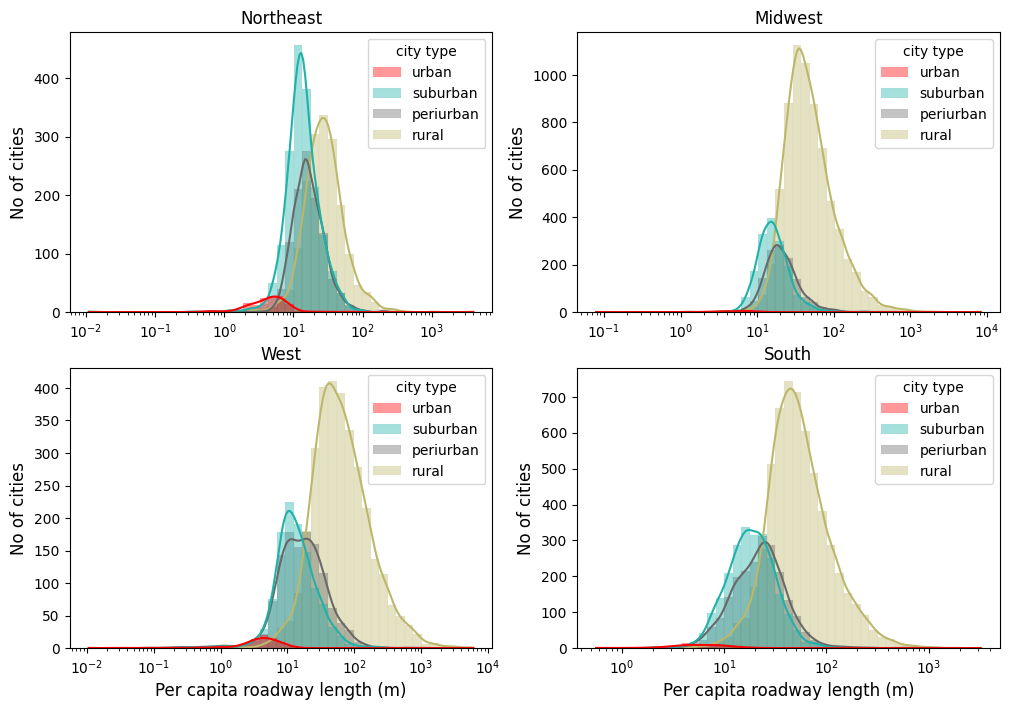

In [11]:
hue = 'city type'
hu_order = ['urban', 'suburban', 'periurban', 'rural']
citytypes = ['Northeast', 'Midwest', 'West', 'South']
fig, axs = plt.subplots(nrows = 2, ncols =2, figsize = (12,8))
ax = axs.flatten()
for i, city in enumerate(citytypes):
    avocado = df_ssp[df_ssp['REGION'] == city]
    sns.histplot(avocado, x = 'length_m_perCap_2020_ssp2', log_scale=True, bins = 45,linewidth=0.01, alpha = .40, hue =hue, hue_order = hu_order, kde=True, kde_kws = {'cut': 0}, ax=ax[i],
                 palette = ['red', 'lightseagreen', 'dimgrey', 'darkkhaki'], ) # ['red', 'orange', 'green', 'tan'],)
    ax[i].set_ylabel("No of cities", fontsize=12)
    ax[i].set_title(city)
    if i >1:
        ax[i].set_xlabel("Per capita roadway length (m)", fontsize=12)
    else:
        ax[i].set_xlabel("", fontsize=10)

In [12]:
df_ssp[['volume_m3_perCap_2020_ssp2', 'length_m_perCap_2020_ssp2']].describe()

,volume_m3_perCap_2020_ssp2,length_m_perCap_2020_ssp2
count,30498.000000,30498.000000
mean,898.715703,52.583272
std,2226.051709,122.185553
min,12.425720,0.010721
25%,582.984951,16.870785
50%,772.854334,29.800670
75%,1023.319295,53.616601
max,341691.085869,8178.395442


In [13]:
print(f"Cities with less than 100 cubic meter/person RBUV:==  {df_ssp[df_ssp['volume_m3_perCap_2020_ssp2'] < 100].shape[0]}")
print(f"Cities with less than 10 m/person roadway:==          {df_ssp[df_ssp['length_m_perCap_2020_ssp2'] < 10].shape[0]}")
print(f"Cities with over 1000 m/person roadway:==             {df_ssp[df_ssp['length_m_perCap_2020_ssp2'] > 1000].shape[0]}")

Cities with less than 100 cubic meter/person RBUV:==  15
Cities with less than 10 m/person roadway:==          2609
Cities with over 1000 m/person roadway:==             45


In [14]:
df_ssp['RBUV_Burden_2050'].value_counts(), df_ssp['RL_Burden_2050'].value_counts(), df_ssp['RBUV_Burden_2100'].value_counts(), df_ssp['RL_Burden_2100'].value_counts()

(RBUV_Burden_2050
 decreasingBurden    15972
 increasingBurden    14516
 noChange               10
 Name: count, dtype: int64,
 RL_Burden_2050
 decreasingBurden    16731
 increasingBurden    13757
 noChange               10
 Name: count, dtype: int64,
 RBUV_Burden_2100
 increasingBurden    19314
 decreasingBurden    11182
 noChange                2
 Name: count, dtype: int64,
 RL_Burden_2100
 increasingBurden    17778
 decreasingBurden    12718
 noChange                2
 Name: count, dtype: int64)

In [ ]:
df_ssp.groupby('STATEFP')[[ 'volume_m3_perCap_2020_ssp2','volume_m3_perCap_2050_ssp2','volume_m3_perCap_2100_ssp2','length_m_perCap_2020_ssp2','length_m_perCap_2050_ssp2', 
                       'length_m_perCap_2100_ssp2']].median().round(1).to_csv(r'E:\Scripts\project_QI\outputfiles\csvs\state_level_median.csv')

In [ ]:
df_ssp[(df_ssp['CensusPop_20']<=10000)].groupby(['STATEFP'])[['volume_m3_perCap_2020_ssp2','volume_m3_perCap_2050_ssp2','volume_m3_perCap_2100_ssp2','length_m_perCap_2020_ssp2',
                                                              'length_m_perCap_2050_ssp2', 'length_m_perCap_2100_ssp2', 'added_RBUV_2020_2050', 'added_RL_2020_2050',
                         'added_RBUV_2050_2100', 'added_RL_2050_2100']].median().round(2).to_csv(r'E:\Scripts\project_QI\outputfiles\csvs\state_level_median_below_10000.csv')

### Constantly increasing burden

In [17]:
condition = (df_ssp['volume_m3_perCap_2020_ssp2'] < df_ssp['volume_m3_perCap_2030_ssp2']) & (df_ssp['volume_m3_perCap_2030_ssp2'] < df_ssp['volume_m3_perCap_2040_ssp2']) & \
(df_ssp['volume_m3_perCap_2040_ssp2'] < df_ssp['volume_m3_perCap_2050_ssp2']) & (df_ssp['volume_m3_perCap_2050_ssp2'] < df_ssp['volume_m3_perCap_2060_ssp2']) & \
(df_ssp['volume_m3_perCap_2060_ssp2'] < df_ssp['volume_m3_perCap_2070_ssp2']) & (df_ssp['volume_m3_perCap_2070_ssp2'] < df_ssp['volume_m3_perCap_2080_ssp2']) & \
(df_ssp['volume_m3_perCap_2080_ssp2'] < df_ssp['volume_m3_perCap_2090_ssp2']) & (df_ssp['volume_m3_perCap_2090_ssp2'] < df_ssp['volume_m3_perCap_2100_ssp2'])
print(f"cities that face constantly increasing burden for RBUV {np.round(df_ssp[condition].shape[0]*100/df_ssp.shape[0],2)}")

condition = (df_ssp['length_m_perCap_2020_ssp2'] < df_ssp['length_m_perCap_2030_ssp2']) & (df_ssp['length_m_perCap_2030_ssp2'] < df_ssp['length_m_perCap_2040_ssp2']) & \
(df_ssp['length_m_perCap_2040_ssp2'] < df_ssp['length_m_perCap_2050_ssp2']) & (df_ssp['length_m_perCap_2050_ssp2'] < df_ssp['length_m_perCap_2060_ssp2']) & \
(df_ssp['length_m_perCap_2060_ssp2'] < df_ssp['length_m_perCap_2070_ssp2']) & (df_ssp['length_m_perCap_2070_ssp2'] < df_ssp['length_m_perCap_2080_ssp2']) & \
(df_ssp['length_m_perCap_2080_ssp2'] < df_ssp['length_m_perCap_2090_ssp2']) & (df_ssp['length_m_perCap_2090_ssp2'] < df_ssp['length_m_perCap_2100_ssp2'])
print(f"cities that face constantly increasing burden for RL {np.round(df_ssp[condition].shape[0]*100/df_ssp.shape[0],2)}")

cities that face constantly increasing burden for RBUV 30.86
cities that face constantly increasing burden for RL 30.82


In [18]:
df_ssp.filter(regex='volume').columns
print("Percent cities with increasing built volumes thereby increasing burden")

column_nmaes1 = ['volume_m3_perCap_2020_ssp2','volume_m3_perCap_2030_ssp2', 'volume_m3_perCap_2040_ssp2','volume_m3_perCap_2050_ssp2', 'volume_m3_perCap_2060_ssp2',
                'volume_m3_perCap_2070_ssp2', 'volume_m3_perCap_2080_ssp2', 'volume_m3_perCap_2090_ssp2']
column_nmaes2 = ['volume_m3_perCap_2030_ssp2', 'volume_m3_perCap_2040_ssp2','volume_m3_perCap_2050_ssp2', 'volume_m3_perCap_2060_ssp2',
                'volume_m3_perCap_2070_ssp2', 'volume_m3_perCap_2080_ssp2', 'volume_m3_perCap_2090_ssp2', 'volume_m3_perCap_2100_ssp2']
for col1, col2 in zip(column_nmaes1, column_nmaes2):
    print(np.round(df_ssp[df_ssp[col2] > df_ssp[col1]].shape[0]*100/df_ssp.shape[0],2))

print("Percent cities with increasing roadways thereby increasing burden")

column_nmaes1 = ['length_m_perCap_2020_ssp2','length_m_perCap_2030_ssp2', 'length_m_perCap_2040_ssp2','length_m_perCap_2050_ssp2', 
                 'length_m_perCap_2060_ssp2','length_m_perCap_2070_ssp2', 'length_m_perCap_2080_ssp2', 'length_m_perCap_2090_ssp2']
column_nmaes2 = ['length_m_perCap_2030_ssp2', 'length_m_perCap_2040_ssp2','length_m_perCap_2050_ssp2', 'length_m_perCap_2060_ssp2',
                 'length_m_perCap_2070_ssp2', 'length_m_perCap_2080_ssp2', 'length_m_perCap_2090_ssp2', 'length_m_perCap_2100_ssp2']
for col1, col2 in zip(column_nmaes1, column_nmaes2):
    print(np.round(df_ssp[df_ssp[col2] > df_ssp[col1]].shape[0]*100/df_ssp.shape[0],2))

Percent cities with increasing built volumes thereby increasing burden
34.05
47.41
52.3
49.4
51.04
57.16
65.3
72.44
Percent cities with increasing roadways thereby increasing burden
33.96
46.95
52.07
49.11
50.66
57.0
65.21
72.29


### Constandtly decreasing burden

In [19]:
condition = (df_ssp['volume_m3_perCap_2020_ssp2'] > df_ssp['volume_m3_perCap_2030_ssp2']) & (df_ssp['volume_m3_perCap_2030_ssp2'] > df_ssp['volume_m3_perCap_2040_ssp2']) & \
            (df_ssp['volume_m3_perCap_2040_ssp2'] > df_ssp['volume_m3_perCap_2050_ssp2']) & (df_ssp['volume_m3_perCap_2050_ssp2'] > df_ssp['volume_m3_perCap_2060_ssp2']) & \
            (df_ssp['volume_m3_perCap_2060_ssp2'] > df_ssp['volume_m3_perCap_2070_ssp2']) & (df_ssp['volume_m3_perCap_2070_ssp2'] > df_ssp['volume_m3_perCap_2080_ssp2']) & \
            (df_ssp['volume_m3_perCap_2080_ssp2'] > df_ssp['volume_m3_perCap_2090_ssp2']) & (df_ssp['volume_m3_perCap_2090_ssp2'] > df_ssp['volume_m3_perCap_2100_ssp2'])
print(f"cities that face constantly decreasing burden for RBUV {np.round(df_ssp[condition].shape[0]*100/df_ssp.shape[0],2)}")

condition = (df_ssp['length_m_perCap_2020_ssp2'] > df_ssp['length_m_perCap_2030_ssp2']) & (df_ssp['length_m_perCap_2030_ssp2'] > df_ssp['length_m_perCap_2040_ssp2']) & \
            (df_ssp['length_m_perCap_2040_ssp2'] > df_ssp['length_m_perCap_2050_ssp2']) & (df_ssp['length_m_perCap_2050_ssp2'] > df_ssp['length_m_perCap_2060_ssp2']) & \
            (df_ssp['length_m_perCap_2060_ssp2'] > df_ssp['length_m_perCap_2070_ssp2']) & (df_ssp['length_m_perCap_2070_ssp2'] > df_ssp['length_m_perCap_2080_ssp2']) & \
            (df_ssp['length_m_perCap_2080_ssp2'] > df_ssp['length_m_perCap_2090_ssp2']) & (df_ssp['length_m_perCap_2090_ssp2'] > df_ssp['length_m_perCap_2100_ssp2'])
print(f"cities that face constantly decreasing burden for RL {np.round(df_ssp[condition].shape[0]*100/df_ssp.shape[0],2)}")

cities that face constantly decreasing burden for RBUV 24.6
cities that face constantly decreasing burden for RL 25.22


In [20]:
df_ssp.filter(regex='volume').columns
print("Percent cities with decreasing built volumes")

column_nmaes1 = ['volume_m3_perCap_2020_ssp2','volume_m3_perCap_2030_ssp2', 'volume_m3_perCap_2040_ssp2','volume_m3_perCap_2050_ssp2', 'volume_m3_perCap_2060_ssp2',
                'volume_m3_perCap_2070_ssp2', 'volume_m3_perCap_2080_ssp2', 'volume_m3_perCap_2090_ssp2']
column_nmaes2 = ['volume_m3_perCap_2030_ssp2', 'volume_m3_perCap_2040_ssp2','volume_m3_perCap_2050_ssp2', 'volume_m3_perCap_2060_ssp2',
                'volume_m3_perCap_2070_ssp2', 'volume_m3_perCap_2080_ssp2', 'volume_m3_perCap_2090_ssp2', 'volume_m3_perCap_2100_ssp2']
for col1, col2 in zip(column_nmaes1, column_nmaes2):
    print(np.round(df_ssp[df_ssp[col2] < df_ssp[col1]].shape[0]*100/df_ssp.shape[0],2))

print("Percent cities with decreasing roadways")

column_nmaes1 = ['length_m_perCap_2020_ssp2','length_m_perCap_2030_ssp2', 'length_m_perCap_2040_ssp2','length_m_perCap_2050_ssp2', 
                 'length_m_perCap_2060_ssp2','length_m_perCap_2070_ssp2', 'length_m_perCap_2080_ssp2', 'length_m_perCap_2090_ssp2']
column_nmaes2 = ['length_m_perCap_2030_ssp2', 'length_m_perCap_2040_ssp2','length_m_perCap_2050_ssp2', 'length_m_perCap_2060_ssp2',
                 'length_m_perCap_2070_ssp2', 'length_m_perCap_2080_ssp2', 'length_m_perCap_2090_ssp2', 'length_m_perCap_2100_ssp2']
for col1, col2 in zip(column_nmaes1, column_nmaes2):
    print(np.round(df_ssp[df_ssp[col2] < df_ssp[col1]].shape[0]*100/df_ssp.shape[0],2))

Percent cities with decreasing built volumes
65.38
52.02
47.08
49.58
48.0
42.24
34.04
27.0
Percent cities with decreasing roadways
65.54
52.54
47.34
49.89
48.39
42.39
34.16
27.15


In [ ]:
df_ssp[['GEOID', 'NAMELSAD', 'city type', 'REGION', 'ALAND','label', 'future trend from SSP 2',
    'CensusPop_20','ssp22030', 'ssp22040', 'ssp22050','ssp22060',
       'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100' ,'volume_m3_perCap_2020_ssp2', 'volume_m3_perCap_2030_ssp2',
       'volume_m3_perCap_2040_ssp2', 'volume_m3_perCap_2050_ssp2',
       'volume_m3_perCap_2060_ssp2', 'volume_m3_perCap_2070_ssp2',
       'volume_m3_perCap_2080_ssp2', 'volume_m3_perCap_2090_ssp2',
       'volume_m3_perCap_2100_ssp2','length_m_perCap_2020_ssp2',
       'length_m_perCap_2030_ssp2', 'length_m_perCap_2040_ssp2',
       'length_m_perCap_2050_ssp2', 'length_m_perCap_2060_ssp2',
       'length_m_perCap_2070_ssp2', 'length_m_perCap_2080_ssp2',
       'length_m_perCap_2090_ssp2', 'length_m_perCap_2100_ssp2',
       'weighted_HU_density_sqmi', 'citytype_at_2030', 'citytype_at_2040', 
       'citytype_at_2050', 'citytype_at_2060', 'citytype_at_2070', 
       'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100', 
       'RBUV_Burden_2050', 'RBUV_Burden_2100','RL_Burden_2050', 'RL_Burden_2100']].to_csv(r'E:\Scripts\project_QI\outputfiles\csvs\df_ssp2_clean.csv')